In [22]:
import matplotlib.pyplot as plt
import noisereduce as nr
import librosa
import librosa.display
import os
import numpy as np

In [2]:
# ładowanie pojedynczego pliku
def load_audio_file(file_path):
    audio_data, sampling_rate = librosa.load(file_path, sr=None)
    return audio_data, sampling_rate

In [13]:
# ustawienie ścieżki
main_directory = os.path.dirname(os.getcwd())
data_directory = "data\\AudioMNIST\\data\\01\\"
file_path = os.path.join(main_directory, data_directory, "0_01_0.wav")
audio_data, sampling_rate = load_audio_file(file_path)
bit_depth = audio_data.dtype
print(sampling_rate)
print(bit_depth)

48000
float32


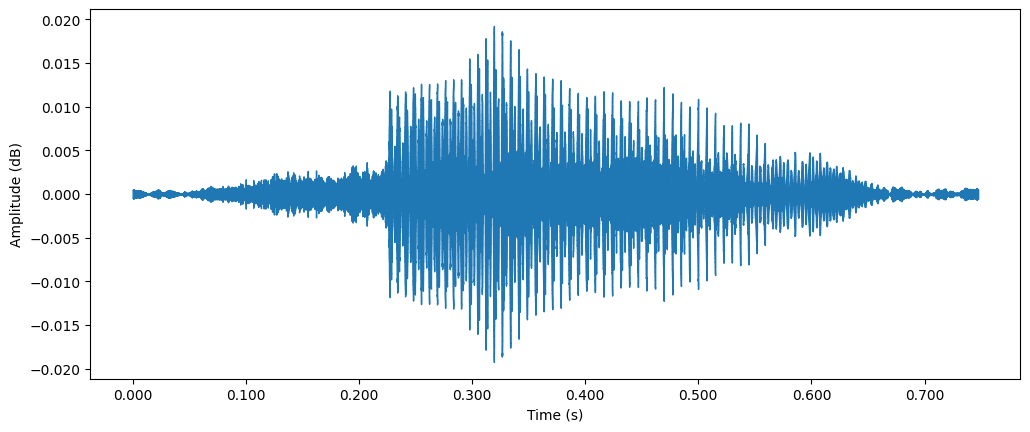

In [15]:
# wizualizacja przebiegu fali
plt.figure().set_figwidth(12)
librosa.display.waveshow(audio_data, sr=sampling_rate)
plt.ylabel("Amplitude (dB)")
plt.xlabel("Time (s)")
plt.show()

In [ ]:
target_sampling_rate = 16000
resampled_audio = librosa.resample(
    audio_data, 
    orig_sr=sampling_rate,
    target_sr=target_sampling_rate)

In [19]:
print(f"Długość oryginalnego audio: {len(audio_data)} próbek ({len(audio_data)/sampling_rate:.2f} sekund)")
print(f"Długość przepróbkowanego audio: {len(resampled_audio)} próbek ({len(resampled_audio)/target_sampling_rate:.2f} sekund)")

Długość oryginalnego audio: 35877 próbek (0.75 sekund)
Długość przepróbkowanego audio: 11959 próbek (0.75 sekund)


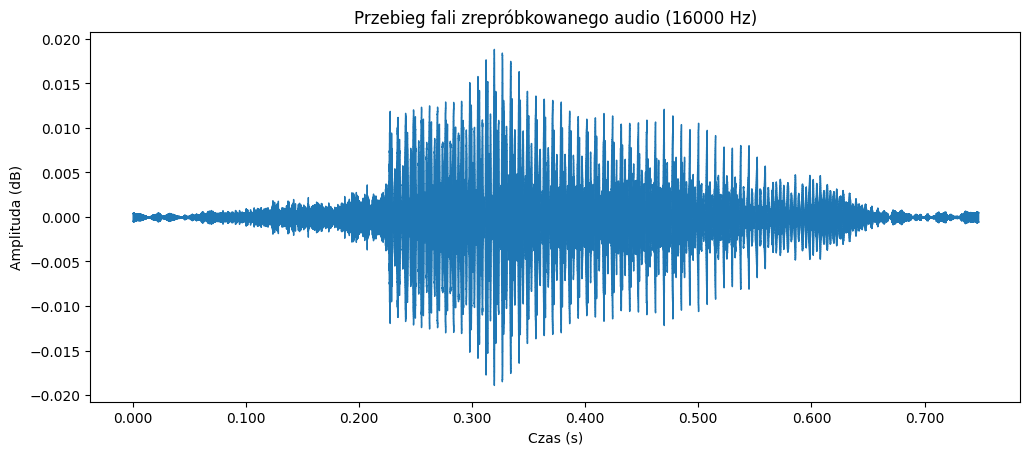

In [25]:
# Wizualizacja przepróbkowanego przebiegu fali
plt.figure().set_figwidth(12)
librosa.display.waveshow(resampled_audio, sr=target_sampling_rate)
plt.ylabel("Amplituda (dB)")
plt.xlabel("Czas (s)")
plt.title(f"Przebieg fali zrepróbkowanego audio ({target_sampling_rate} Hz)")
plt.show()

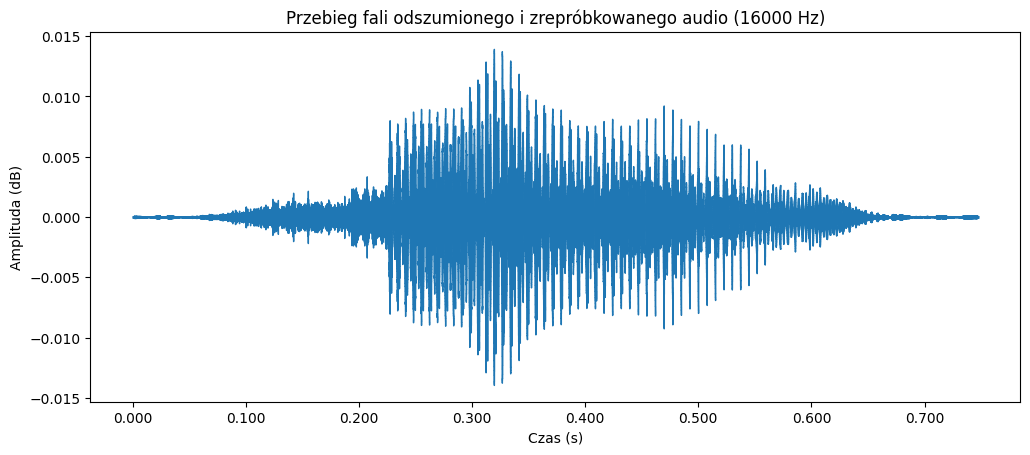

In [ ]:
# Odszumianie
## Odszumianie audio
denoised_audio = nr.reduce_noise(y=resampled_audio, sr=target_sampling_rate)
## wizualizacja
plt.figure().set_figwidth(12)
librosa.display.waveshow(denoised_audio, sr=target_sampling_rate)
plt.ylabel("Amplituda (dB)")
plt.xlabel("Czas (s)")
plt.title(f"Przebieg fali odszumionego i zrepróbkowanego audio ({target_sampling_rate} Hz)")
plt.show()
# spectral gating technique?

In [30]:
# ustawienie ścieżki
main_directory = os.path.dirname(os.getcwd())
data_directory = "data\\AudioMNIST\\data\\"
file_path = os.path.join(main_directory, data_directory, 'audioMNIST_meta.txt')

In [ ]:
# Wczytanie jsona metadanych
def load_metadata(file_path):
    with open(file_path, 'r') as f:
        metadata = json.load(f)
    return metadata
# Konwersja do ramki danych
def metadata_to_df(metadata):
    df = pd.DataFrame.from_dict(metadata, orient='index')
    
    # Convert all string columns to lowercase
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.lower()
    # wiek -> liczba
    df['age'] = pd.to_numeric(df['age'], downcast='float')
    # obserwacja odstająca:
    df.loc[df['age'] > 100, 'age'] = df['age'].mean()
    return df

In [ ]:
# Wczytanie i przetworzenie metadanych
main_directory = os.path.dirname(os.getcwd())
metadata_path = os.path.join(main_directory, "data/AudioMNIST/data/audioMNIST_meta.json")
metadata = load_metadata(metadata_path)
metadata_df = metadata_to_df(metadata)

In [63]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 01 to 60
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   accent          60 non-null     object 
 1   age             60 non-null     float32
 2   gender          60 non-null     object 
 3   native speaker  60 non-null     object 
 4   origin          60 non-null     object 
 5   recordingdate   60 non-null     object 
 6   recordingroom   60 non-null     object 
dtypes: float32(1), object(6)
memory usage: 5.6+ KB


In [64]:
metadata_df.isna().sum()

accent            0
age               0
gender            0
native speaker    0
origin            0
recordingdate     0
recordingroom     0
dtype: int64

In [65]:
metadata_df

,accent,age,gender,native speaker,origin,recordingdate,recordingroom
01,german,30.000000,male,no,"europe, germany, wuerzburg",17-06-22-11-04-28,kino
02,german,25.000000,male,no,"europe, germany, hamburg",17-06-26-17-57-29,kino
03,german,31.000000,male,no,"europe, germany, bremen",17-06-30-17-34-51,kino
04,german,23.000000,male,no,"europe, germany, helmstedt",17-06-30-18-09-14,kino
05,german,25.000000,male,no,"europe, germany, hameln",17-07-06-10-53-10,kino
06,german,25.000000,male,no,"europe, germany, dortmund",17-07-06-11-23-34,kino
07,german/spanish,27.000000,male,no,"europe, spanien, mallorca",17-07-10-17-06-17,kino
08,german,41.000000,male,no,"europe, germany, ludwigsfelde",17-07-10-17-39-41,kino
09,south korean,35.000000,male,no,"asia, south korea, seoul",17-07-12-17-03-59,kino
10,german,36.000000,male,no,"europe, germany, lemgo",17-07-12-17-31-43,kino
